In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
import contractions
from nltk import ngrams
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost
from sklearn import metrics
import pickle

In [3]:
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

In [4]:
data = pd.read_csv("dataset/mb_data.csv")

In [5]:
def fix_contractions(text):
    return contractions.fix(text)

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"@([a-zA-Z0-9_]{1,50})", "", text)
    text = re.sub(r"#([a-zA-Z0-9_]{1,50})", "", text)
    text = re.sub(r"http[s]?://\S+", "", text)
    text = re.sub(r"[^A-Za-z]+", " ", text)
    text = re.sub(r" +", " ", text)
    return " ".join([word for word in text.split() if len(word) >= 3])

In [7]:
def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

In [8]:
# Clean and preprocess data
data["cleaned_post"] = data["posts"].apply(fix_contractions)
data["cleaned_post"] = data["cleaned_post"].apply(clean_text)
data["cleaned_post"] = data["cleaned_post"].apply(lemmatize_text)

In [9]:
# Divide MBTI types
def divide_types(df):
    df["E-I"] = df["type"].apply(lambda x: x[0])
    df["N-S"] = df["type"].apply(lambda x: x[1])
    df["F-T"] = df["type"].apply(lambda x: x[2])
    df["J-P"] = df["type"].apply(lambda x: x[3])
    return df


data = divide_types(data)

In [10]:
# Visualization functions
def show_class_distribution(
    data,
    x="type",
    figsize=(16, 4),
    title="Distribution of Personality Types",
    xticks_size=10,
    palette="husl",
):
    plt.figure(figsize=figsize)
    sns.countplot(x=x, data=data, palette=palette)
    plt.xlabel("Personality Types", size=15)
    plt.ylabel("Counts", size=15)
    plt.xticks(size=xticks_size)
    plt.title(title, size=20)
    plt.show()

In [11]:
def show_wordcloud(data, stopwords, column="cleaned_post"):
    wordcloud = WordCloud(
        background_color="black", min_font_size=5, stopwords=stopwords
    ).generate(data[column].to_string())
    plt.figure(figsize=(15, 5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()

In [12]:
def plot_n_grams(ngrams, title, top=20):
    ngram_df = pd.DataFrame(ngrams, columns=["Ngram", "Count"])
    plt.figure(figsize=(10, 8))
    plt.barh(y=ngram_df["Ngram"][:top], width=ngram_df["Count"][:top])
    plt.xlabel("Counts", size=12)
    plt.ylabel("N-grams", size=12)
    plt.title(title, size=14)
    plt.show()

In [13]:
# N-gram analysis
def get_ngrams(data, n, column="cleaned_post"):
    all_ngrams = []
    for text in data[column]:
        tokens = text.split()
        all_ngrams.extend(list(ngrams(tokens, n)))
    return Counter(all_ngrams).most_common(20)

In [14]:
# Prepare data for modeling
X = data["cleaned_post"]
y_ei = data["E-I"]
y_ns = data["N-S"]
y_ft = data["F-T"]
y_jp = data["J-P"]

In [15]:
# Oversample to balance classes
oversample = RandomOverSampler(random_state=42)

In [16]:
def oversample_and_split(X, y):
    X_reshaped = X.to_frame()
    X_over, y_over = oversample.fit_resample(X_reshaped, y)
    X_train, X_test, y_train, y_test = train_test_split(
        X_over, y_over, test_size=0.3, random_state=42
    )
    return X_train.iloc[:, 0], X_test.iloc[:, 0], y_train, y_test

In [17]:
X_train_ei, X_test_ei, y_train_ei, y_test_ei = oversample_and_split(X, y_ei)
X_train_ns, X_test_ns, y_train_ns, y_test_ns = oversample_and_split(X, y_ns)
X_train_ft, X_test_ft, y_train_ft, y_test_ft = oversample_and_split(X, y_ft)
X_train_jp, X_test_jp, y_train_jp, y_test_jp = oversample_and_split(X, y_jp)

In [18]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=10000)
X_train_ei_tfidf = vectorizer.fit_transform(X_train_ei)
X_test_ei_tfidf = vectorizer.transform(X_test_ei)

In [19]:
# Use the same vectorizer for other personality dimensions
X_train_ns_tfidf = vectorizer.transform(X_train_ns)
X_test_ns_tfidf = vectorizer.transform(X_test_ns)
X_train_ft_tfidf = vectorizer.transform(X_train_ft)
X_test_ft_tfidf = vectorizer.transform(X_test_ft)
X_train_jp_tfidf = vectorizer.transform(X_train_jp)
X_test_jp_tfidf = vectorizer.transform(X_test_jp)

In [20]:
# Model creation
def create_models():
    return {
        "NaiveBayes": MultinomialNB(alpha=0.01),
        "SVM": SVC(C=1.0, kernel="linear", degree=3, gamma="auto"),
        "DecisionTree": DecisionTreeClassifier(max_depth=7),
        "RandomForest": RandomForestClassifier(n_estimators=750),
        "Xgboost": xgboost.XGBClassifier(use_label_encoder=False),
    }

In [21]:
# Model evaluation
def evaluate_models(models, X_trains, X_tests, y_trains, y_tests):
    metrics_list = ["Accuracy", "Precision", "Recall", "F1-Score", "Roc-Auc Score"]
    types = ["E-I", "N-S", "F-T", "J-P"]
    evaluation_df = pd.DataFrame(
        index=pd.MultiIndex.from_product([metrics_list, types]), columns=models.keys()
    )

    for model_name, model in models.items():
        for X_train, X_test, y_train, y_test in zip(
            X_trains, X_tests, y_trains, y_tests
        ):
            print(f"{model_name} is training for {y_train.name}...")
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            evaluation_df.loc[("Accuracy", y_train.name), model_name] = round(
                metrics.accuracy_score(y_test, pred), 3
            )
            evaluation_df.loc[("Precision", y_train.name), model_name] = round(
                metrics.precision_score(y_test, pred, average="weighted"), 3
            )
            evaluation_df.loc[("Recall", y_train.name), model_name] = round(
                metrics.recall_score(y_test, pred, average="weighted"), 3
            )
            evaluation_df.loc[("F1-Score", y_train.name), model_name] = round(
                metrics.f1_score(y_test, pred, average="weighted"), 3
            )
            evaluation_df.loc[("Roc-Auc Score", y_train.name), model_name] = round(
                metrics.roc_auc_score(y_test, pred, average="weighted"), 3
            )

            # Save model
            filename = f"saved-models/{model_name}_{y_test.name}.sav"
            pickle.dump(model, open(filename, "wb"))

    return evaluation_df

C:\Users\Kumar Malay\AppData\Local\Temp\ipykernel_24528\2486211577.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=x, data=data, palette=palette)


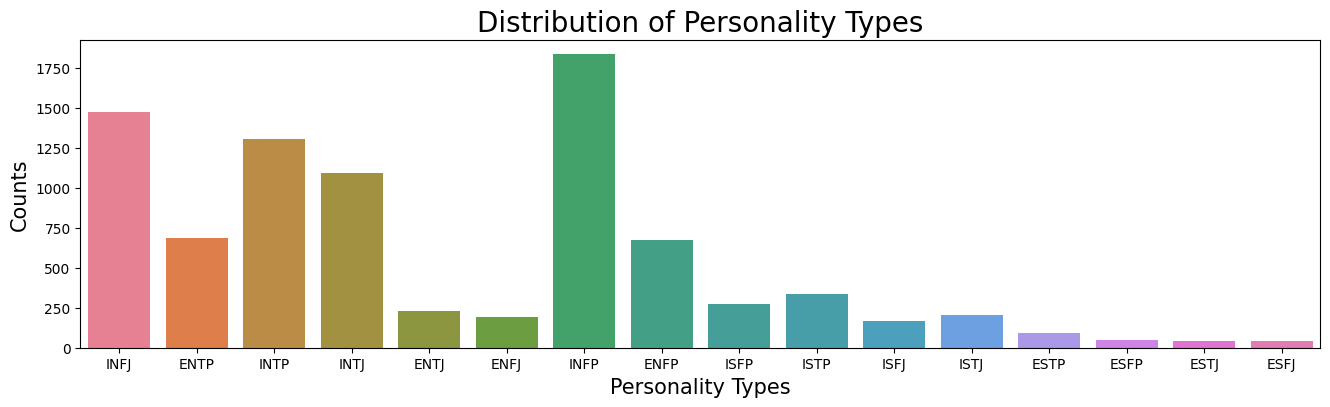

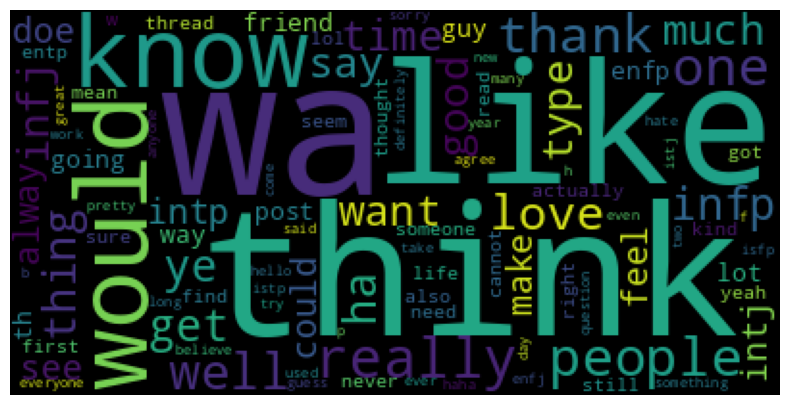

TypeError: 'value' must be an instance of str or bytes, not a tuple

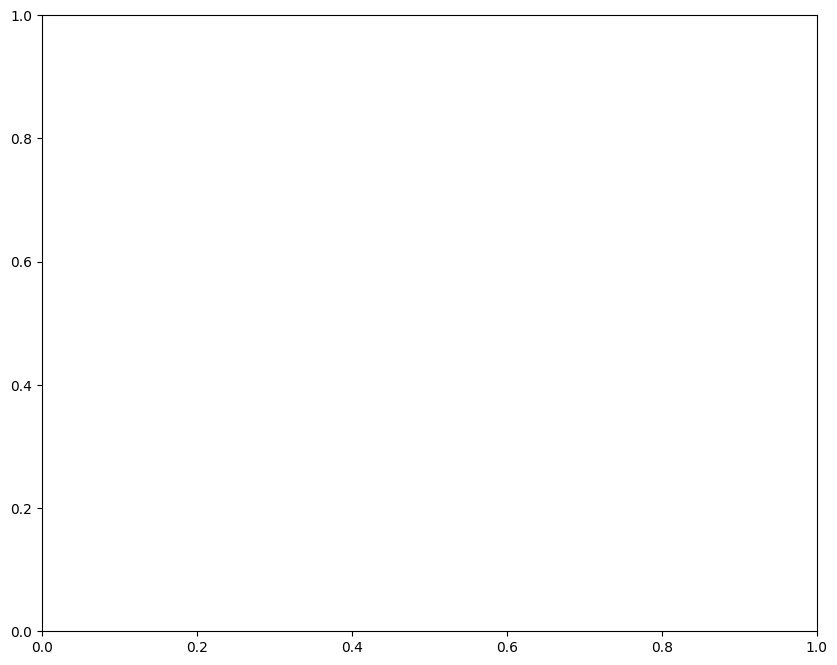

In [23]:
# Main execution
if __name__ == "__main__":
    # Visualizations
    show_class_distribution(data)
    show_wordcloud(data, stopwords.words("english"))

    # N-gram analysis
    bigrams = get_ngrams(data, 2)
    trigrams = get_ngrams(data, 3)
    plot_n_grams(bigrams, "Most Frequent Bigrams")
    plot_n_grams(trigrams, "Most Frequent Trigrams")

    # Model training and evaluation
    models = create_models()
    X_trains = [X_train_ei_tfidf, X_train_ns_tfidf, X_train_ft_tfidf, X_train_jp_tfidf]
    X_tests = [X_test_ei_tfidf, X_test_ns_tfidf, X_test_ft_tfidf, X_test_jp_tfidf]
    y_trains = [y_train_ei, y_train_ns, y_train_ft, y_train_jp]
    y_tests = [y_test_ei, y_test_ns, y_test_ft, y_test_jp]

    evaluation_results = evaluate_models(models, X_trains, X_tests, y_trains, y_tests)
    print(evaluation_results)

    # Save TF-IDF Vectorizer
    pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))